In [ ]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
ART_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)
import pandas as pd
from datetime import timedelta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")

# Этап 1. Организация и ĸонтраĸт данных

2. Проверить ĸлючи и связĸи

message_id в обеих таблицах, дублиĸаты, пропусĸи, 1:N / N:1.

In [3]:
data = pd.read_csv(DATA_DIR / "messages_with_reactions.csv")


In [4]:
data.shape

(7026594, 19)

In [5]:
data.head()

,id,message_id,date,message,id_channel,message_vector,text_len,word_count,hour,dayofweek,cur_date,views,forwards,replies,reactions,delta_views,delta_forwards,delta_replies,delta_reactions
0,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-02 00:00:00+00:00,843036,212,0,0,1,0,0,0
1,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-23 00:00:00+00:00,844036,212,0,0,44429,0,0,0
2,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-24 00:00:00+00:00,844038,212,0,0,2,0,0,0
3,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-25 00:00:00+00:00,844038,212,0,0,0,0,0,0
4,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-26 00:00:00+00:00,844039,212,0,0,1,0,0,0


In [20]:
data['message_id'].unique().shape   

(109795,)

In [22]:
data['message'].unique().shape   

(122660,)

In [21]:
data['id'].unique().shape   

(123273,)

In [18]:
data[['message_id', 'cur_date']].drop_duplicates().shape

(6830802, 2)

In [19]:
data[['id', 'cur_date']].drop_duplicates().shape

(7026594, 2)

In [ ]:
df_msgs = pd.read_excel(DATA_DIR / "all_tg_1610.xlsx") # новости
df_msgs.shape


/Users/aselkarakuchukova/Library/Python/3.9/lib/python/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


(123273, 6)

In [67]:
df_msgs.head(3)

,id,message_id,date,message,id_channel,message_vector
0,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...
1,792632e5-da04-4341-a674-f8405c8ddd71,275547,2025-01-02 16:40:53,В ДТП с туристическим автобусом в Таиланде пос...,3,'27':9 'автобус':5 'возвращен':31 'гостиниц':3...
2,dcb05245-5965-4003-81a5-421043394def,275546,2025-01-02 16:20:12,Премьер Израиля Нетаньяху выписан из больницы ...,3,'jerusalem':14 'post':15 'больниц':6 'выписа':...


In [70]:
print("Пропуски:")
print(df_msgs.isna().sum())

Пропуски:
id                 0
message_id         0
date               0
message            0
id_channel         0
message_vector    10
dtype: int64


In [71]:
pair_unique = df_msgs[["id_channel", "message_id"]].drop_duplicates().shape[0]
print("\nУникальных пар (id_channel, message_id):", pair_unique)
print("Всего строк:", len(msgs))
print("Дубликатов по паре:", len(msgs) - pair_unique)


Уникальных пар (id_channel, message_id): 123273
Всего строк: 123273
Дубликатов по паре: 0


In [72]:
print("\nУникальных message_id:", df_msgs["message_id"].nunique())
print("Уникальных message:", df_msgs["message"].nunique())


Уникальных message_id: 109795
Уникальных message: 122660


In [73]:
# какие message_id встречаются в нескольких строках?
dup_ids = df_msgs["message_id"].value_counts()
print("\nmessage_id, встречающиеся более одного раза:")
print(dup_ids[dup_ids > 1].head(10))


message_id, встречающиеся более одного раза:
message_id
35862    2
71059    2
71087    2
71086    2
71085    2
71084    2
71083    2
71082    2
71081    2
71080    2
Name: count, dtype: int64


In [74]:
# для примера покажем тексты у одного из таких message_id
sample_id = dup_ids[dup_ids > 1].index[0]
df_msgs[df_msgs["message_id"] == sample_id][["id_channel", "date", "message"]]

,id_channel,date,message
33842,4,2024-12-13 13:27:18,В США впервые осудили криптана за уход от упла...
38585,18,2025-01-16 15:07:08,Санкции и их отмена могут сыграть важную роль ...


In [ ]:
# будем использовать ключ message_uid = f"{id_channel}:{message_id}"
# он гарантированно уникален во всех данных.

In [75]:
df_msgs["message_uid"] = df_msgs["id_channel"].astype(str) + ":" + df_msgs["message_id"].astype(str)

print("Уникальных message_uid:", df_msgs["message_uid"].nunique())
print("Совпадает ли с числом строк:", df_msgs["message_uid"].nunique() == len(df_msgs))

Уникальных message_uid: 123273
Совпадает ли с числом строк: True


In [15]:
# Проверка уникальности id
is_unique_id = df_msgs["id"].is_unique
print("Поле 'id' уникально:", is_unique_id)

# Проверим дубликаты, если они есть
if not is_unique_id:
    dup_ids = df_msgs[df_msgs.duplicated("id", keep=False)].sort_values("id")
    print(f"Количество дубликатов: {dup_ids['id'].nunique()}")
    display(dup_ids.head(5))
else:
    print("Дубликатов по 'id' нет, можно использовать как уникальный ключ.")


Поле 'id' уникально: True
Дубликатов по 'id' нет, можно использовать как уникальный ключ.


In [16]:
# однако в датасете с реакциями другое идентификатор используется -> ключ, по которому будем джойнить: 
# id (messages) -> message_id (reactions)

## Результаты

**Таблица all_tg_1610 (сообщения)**

| Поле             | Описание                                                 | Проверка                       |
| ---------------- | -------------------------------------------------------- | ------------------------------ |
| `id`             | **Уникальный идентификатор сообщения (глобальный ключ)** | уникален                       |
| `message_id`     | локальный ID внутри канала                               | не используется при связывании |
| `id_channel`     | идентификатор канала                                     | без пропусков                  |
| `date`           | дата публикации                                          | без пропусков                  |
| `message`        | текст сообщения                                          | без пропусков                  |
| `message_vector` | векторное представление текста                           | 10 пропусков (некритично)      |

Ключ таблицы: id


Связь с реакциями: id (all_tg_1610) <-> message_id (reactions_all_tg_1610)




# Этап 2. EDA и sanity-check
1. Базовый EDA по сообщениям

Распределения длины теĸста, частоты по
ĸаналам, сезонность по часу/дню.

In [ ]:
print("Размер:", df_msgs.shape)
print("\nТипы данных:")
print(df_msgs.dtypes)
print("\nДиапазон дат:")
print(df_msgs["date"].min(), "→", df_msgs["date"].max())

# добавим длину текста
df_msgs["text_len"] = df_msgs["message"].astype(str).str.len()
df_msgs["word_count"] = df_msgs["message"].astype(str).str.split().str.len()

df_msgs[["text_len", "word_count"]].describe().round(1)

Размер: (123273, 6)

Типы данных:
id                        object
message_id                 int64
date              datetime64[ns]
message                   object
id_channel                 int64
message_vector            object
dtype: object

Диапазон дат:
2023-09-23 17:01:04 → 2025-09-08 22:26:58


,text_len,word_count
count,123273.0,123273.0
mean,355.9,49.4
std,312.5,43.4
min,1.0,1.0
25%,147.0,21.0
50%,267.0,37.0
75%,464.0,64.0
max,4075.0,687.0


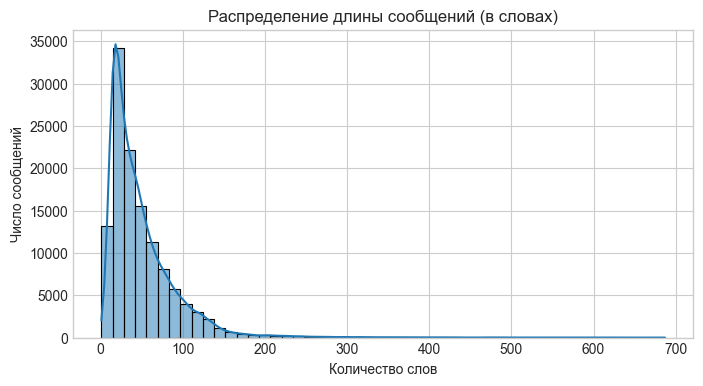

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df_msgs["word_count"], bins=50, kde=True)
plt.title("Распределение длины сообщений (в словах)")
plt.xlabel("Количество слов")
plt.ylabel("Число сообщений")
plt.show()


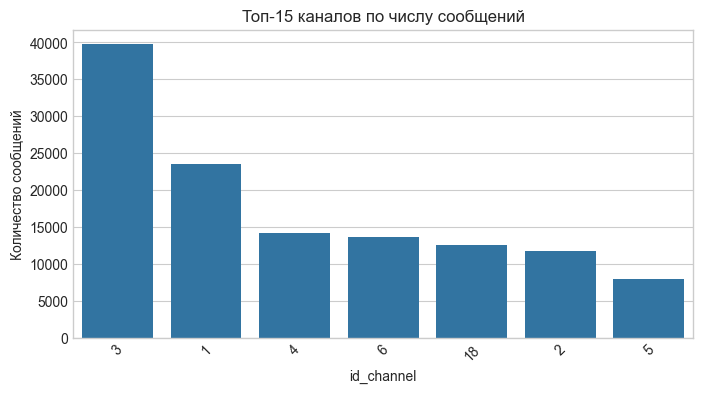

In [13]:
top_channels = df_msgs["id_channel"].value_counts().head(15)

plt.figure(figsize=(8,4))
sns.barplot(x=top_channels.index.astype(str), y=top_channels.values)
plt.title("Топ-15 каналов по числу сообщений")
plt.xlabel("id_channel")
plt.ylabel("Количество сообщений")
plt.xticks(rotation=45)
plt.show()


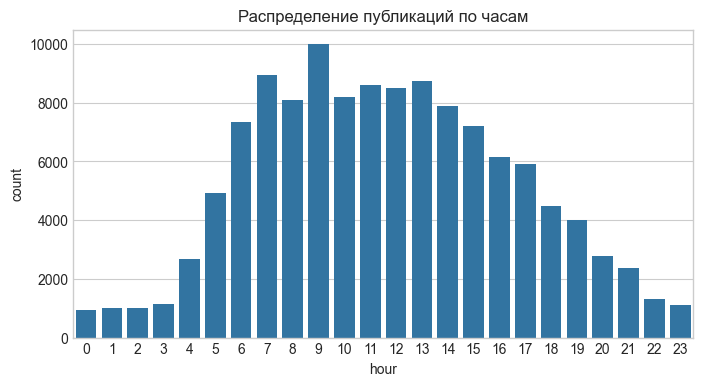

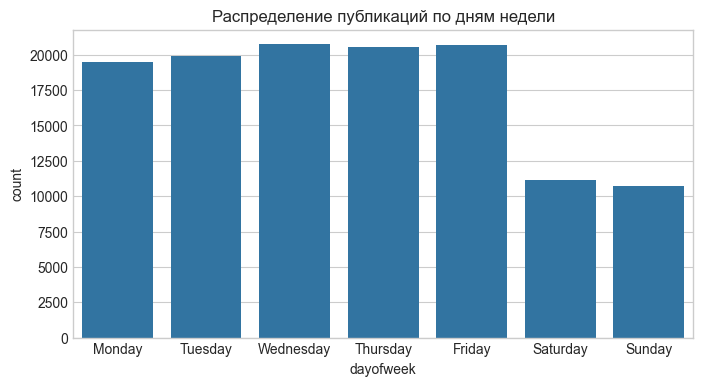

In [14]:
# убедимся, что date — datetime
df_msgs["date"] = pd.to_datetime(df_msgs["date"], errors="coerce")

df_msgs["hour"] = df_msgs["date"].dt.hour
df_msgs["dayofweek"] = df_msgs["date"].dt.day_name()

plt.figure(figsize=(8,4))
sns.countplot(x="hour", data=df_msgs)
plt.title("Распределение публикаций по часам")
plt.show()

plt.figure(figsize=(8,4))
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sns.countplot(x="dayofweek", data=df_msgs, order=order)
plt.title("Распределение публикаций по дням недели")
plt.show()


## Результаты 

-----------------------------------------


**Общая информация**

Количество сообщений: 123 273

Период данных: с 2023-09-23 по 2025-09-08

Каналов: 18 (идентификаторы от 1 до 18)

Отсутствуют пропуски в ключевых полях (message_id, message, date, id_channel)

Есть 10 пропусков в message_vector — можно будет позже удалить или заменить.

----------------------------------------------------------------------------------

**Длина сообщений**

Средняя длина	~ 355 символов / 49 слов
Медиана	~ 267 символов / 37 слов
Макс. длина	~ 4075 символов / 687 слов

Распределение: сильно скошено вправо.

Больше 80 % сообщений — короткие (до 100 слов), что типично для новостных каналов.
Есть хвост длинных аналитических публикаций (до нескольких сотен слов) — их немного, но они могут иметь другую динамику вирусности.

----------------------------------------------------------------------------------

**Частота сообщений по каналам**

Топ-3 активных канала:

id_channel = 3 (~39 000 сообщений)

id_channel = 1 (~24 000 сообщений)

id_channel = 4 (~13 000 сообщений)

-> сильный дисбаланс между источниками:
~30 % всех сообщений приходятся на один канал.
При обучении модели это важно учитывать (возможен oversampling или стратификация).

----------------------------------------------------------------------------------


**Сезонность публикаций**

По часам: пик активности с 8:00 до 15:00, максимум около 10 утра → рабочее время редакций.


По дням недели: публикации равномерны с понедельника по пятницу, снижение в субботу и воскресенье (~в 1.5 раза меньше).


Это типичная картина для медиа-контента (новостной цикл).

# Этап 3. Формализация таргета (что таĸое «вирусная»)
1. Сбор целевых метрик на горизонте H
    * Для каждого message_id посчитать views_H, forwards_H, reactions_H на горизонтах H ∈ {24h, 48h}.
    * Использовать только строки reactions_all_tg_1610 с cur_date ≤ t0+H. Артефакт: table message_targets.parquet.
2. Определение класса
    * Бинарный таргет: viral=1, если forwards_H ≥ Q_{0.9} внутри «дата-бина» (например, по неделе публикации).
    * Сохранить и порог, и квантиль. Артефакт: spec target_definition.yaml, колонка viral_label.

## Объединение таблиц

In [ ]:
df_react = pd.read_csv(DATA_DIR / "reactions_all_tg_1610_unique.csv")
df_react.shape


(7026594, 12)

In [18]:
df_react.head(3)

,id,id_channel,cur_date,message_id,views,forwards,replies,reactions,delta_views,delta_forwards,delta_replies,delta_reactions
0,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-07,00027151-a524-4d93-a820-116398fb81bb,492127,381,0,0,0,0,0,0
1,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-08,00027151-a524-4d93-a820-116398fb81bb,603269,415,0,0,111142,34,0,0
2,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-09,00027151-a524-4d93-a820-116398fb81bb,619397,449,0,0,16128,34,0,0


In [19]:
# Сравним количество совпадающих ID между таблицами
shared_ids = df_msgs["id"].astype(str).isin(df_react["message_id"].astype(str)).sum()
print(f"Совпадающих id между сообщениями и реакциями: {shared_ids:,} ({shared_ids / len(df_msgs):.2%})")

Совпадающих id между сообщениями и реакциями: 123,273 (100.00%)


**Связь между таблицами**

| Проверка | Результат |
|-----------|------------|
| Поля для связи | `messages.id` ↔ `reactions.message_id` |
| Совпадений | **123 273 (100%)** |
| Тип связи | **1:N** - одно сообщение имеет несколько записей по датам|
| Конфликты текстов/дат | отсутствуют |
| Пропуски | отсутствуют |

In [20]:
df_msgs.dtypes

id                        object
message_id                 int64
date              datetime64[ns]
message                   object
id_channel                 int64
message_vector            object
text_len                   int64
word_count                 int64
hour                       int32
dayofweek                 object
dtype: object

In [21]:
df_react.dtypes

id                 object
id_channel          int64
cur_date           object
message_id         object
views               int64
forwards            int64
replies             int64
reactions           int64
delta_views         int64
delta_forwards      int64
delta_replies       int64
delta_reactions     int64
dtype: object

In [22]:
df_msgs["id"] = df_msgs["id"].astype(str)
df_react["message_id"] = df_react["message_id"].astype(str)

df_msgs["id_channel"] = df_msgs["id_channel"].astype(str)
df_react["id_channel"] = df_react["id_channel"].astype(str)


In [23]:
print("Уникальность ключей:")
print("Сообщения (id):", df_msgs["id"].is_unique)
print("Реакции (message_id, cur_date):", not df_react.duplicated(["message_id", "cur_date"]).any())


Уникальность ключей:
Сообщения (id): True
Реакции (message_id, cur_date): True


In [24]:
# Сколько сообщений имеют хотя бы одну реакцию
ids_with_reacts = df_react["message_id"].nunique()
ids_total = df_msgs["id"].nunique()
print(f"Сообщений с реакциями: {ids_with_reacts} ({ids_with_reacts / ids_total:.2%} покрытия)")


Сообщений с реакциями: 123273 (100.00% покрытия)


In [25]:
df_msgs["date"] = pd.to_datetime(df_msgs["date"], errors="coerce", utc=True)
df_react["cur_date"] = pd.to_datetime(df_react["cur_date"], errors="coerce", utc=True)

print("Диапазон дат сообщений:", df_msgs["date"].min(), "→", df_msgs["date"].max())
print("Диапазон дат реакций:", df_react["cur_date"].min(), "→", df_react["cur_date"].max())


Диапазон дат сообщений: 2023-09-23 17:01:04+00:00 → 2025-09-08 22:26:58+00:00
Диапазон дат реакций: 2024-01-16 00:00:00+00:00 → 2025-09-08 00:00:00+00:00


In [ ]:
df_join_check = df_msgs.merge(
    df_react, left_on="id", right_on="message_id", how="left", indicator=True
)

print(df_join_check["_merge"].value_counts(normalize=True))
# (если left_only не ноль — это значит, что часть сообщений пока без реакций, и это ок)

_merge
both          1.0
left_only     0.0
right_only    0.0
Name: proportion, dtype: float64


In [27]:
print("Размер объединённого датафрейма:", df_join_check.shape)
df_join_check.head(3)

Размер объединённого датафрейма: (7026594, 23)


,id_x,message_id_x,date,message,id_channel_x,message_vector,text_len,word_count,hour,dayofweek,...,message_id_y,views,forwards,replies,reactions,delta_views,delta_forwards,delta_replies,delta_reactions,_merge
0,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,...,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,843036,212,0,0,1,0,0,0,both
1,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,...,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,844036,212,0,0,44429,0,0,0,both
2,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,...,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,844038,212,0,0,2,0,0,0,both


In [30]:
print("Пропуски после объединения:")
print(df_join_check.isna().sum())

print("Количество уникальных сообщений:", df_join_check["id_x"].nunique())
print("Количество строк (учитывая реакции по дням):", len(df_join_check))
print("Количество уникальных message_id (реакций):", df_join_check["message_id_y"].nunique())


Пропуски после объединения:
id_x                 0
message_id_x         0
date                 0
message              0
id_channel_x         0
message_vector     953
text_len             0
word_count           0
hour                 0
dayofweek            0
id_y                 0
id_channel_y         0
cur_date             0
message_id_y         0
views                0
forwards             0
replies              0
reactions            0
delta_views          0
delta_forwards       0
delta_replies        0
delta_reactions      0
_merge               0
dtype: int64
Количество уникальных сообщений: 123273
Количество строк (учитывая реакции по дням): 7026594
Количество уникальных message_id (реакций): 123273


In [41]:
df_full = df_join_check.rename(columns={
    "id_x": "id",
    "message_id_x": "message_id",
    "id_channel_x": "id_channel",
}).drop(columns=["id_y", "id_channel_y", "_merge", 'message_id_y'])
df_full.columns

Index(['id', 'message_id', 'date', 'message', 'id_channel', 'message_vector',
       'text_len', 'word_count', 'hour', 'dayofweek', 'cur_date', 'views',
       'forwards', 'replies', 'reactions', 'delta_views', 'delta_forwards',
       'delta_replies', 'delta_reactions'],
      dtype='object')

| Таблица              | Мин. дата  | Макс. дата |
| -------------------- | ---------- | ---------- |
| `messages.date`      | 2023-09-23 | 2025-09-08 |
| `reactions.cur_date` | 2024-01-16 | 2025-09-08 |


In [43]:
print("Пропуски после объединения:")
print(df_full.isna().sum())

print("Количество уникальных сообщений:", df_full["id"].nunique())
print("Количество строк (учитывая реакции по дням):", len(df_full))
print("Количество уникальных message_id (реакций):", df_full["message_id"].nunique())

Пропуски после объединения:
id                   0
message_id           0
date                 0
message              0
id_channel           0
message_vector     953
text_len             0
word_count           0
hour                 0
dayofweek            0
cur_date             0
views                0
forwards             0
replies              0
reactions            0
delta_views          0
delta_forwards       0
delta_replies        0
delta_reactions      0
dtype: int64
Количество уникальных сообщений: 123273
Количество строк (учитывая реакции по дням): 7026594
Количество уникальных message_id (реакций): 109795


In [44]:
df_full.head(10)

,id,message_id,date,message,id_channel,message_vector,text_len,word_count,hour,dayofweek,cur_date,views,forwards,replies,reactions,delta_views,delta_forwards,delta_replies,delta_reactions
0,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-02 00:00:00+00:00,843036,212,0,0,1,0,0,0
1,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-23 00:00:00+00:00,844036,212,0,0,44429,0,0,0
2,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-24 00:00:00+00:00,844038,212,0,0,2,0,0,0
3,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-25 00:00:00+00:00,844038,212,0,0,0,0,0,0
4,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-26 00:00:00+00:00,844039,212,0,0,1,0,0,0
5,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-27 00:00:00+00:00,844039,212,0,0,0,0,0,0
6,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-28 00:00:00+00:00,844039,212,0,0,0,0,0,0
7,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-29 00:00:00+00:00,844039,212,0,0,0,0,0,0
8,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-30 00:00:00+00:00,845039,212,0,0,1000,0,0,0
9,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-31 00:00:00+00:00,845040,212,0,0,1,0,0,0


In [45]:
df_full.to_csv(
    "messages_with_reactions.csv",
    index=False
)

| Категория         | Признаки                                      | Пример                                 |
| ----------------- | --------------------------------------------- | -------------------------------------- |
| **Текстовые**     | `text_len`, `word_count`, частотность токенов | длина сообщения, лексическая плотность |
| **Временные**     | `hour`, `dayofweek`                           | пост в утренние часы vs вечерние       |
| **Контентные**    | `message_vector`                              | вектор текста                          |
| **Поведенческие** | `views_t0`, `delta_views_t1d`, `forwards_t1d` | первые сутки после поста               |
| **Канальные**     | `id_channel`, средняя активность канала       | нормировка по аудитории                |


#### **Гетерогенный граф экономических нарративов**

**Узлы**
| Тип узла              | Обозначение                               | Описание                                                      | Примеры атрибутов                                                                                      |
| --------------------- | ----------------------------------------- | ------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------ |
| **Channel**           | `id_channel`                              | Telegram-канал, публикующий экономические новости             | частота публикаций, средний рост просмотров, средний `growth_24h`, доля постов с экономическим смыслом |
| **Message**           | `id`                                      | Конкретная публикация, кандидат в экономический нарратив      | `text_len`, `word_count`, `views_t0`, `growth_24h`, `viral`, embedding (BERT/ruBERT)                   |
| **Topic (Narrative)** | кластер из эмбеддингов (`message_vector`) | Семантически однородная группа сообщений (экономическая тема) | `ключевые слова`, средний рост вирусности внутри темы, время жизни темы                                |


**Рёбра**
| Связь                           | Интерпретация                                             | Пример                                     | Возможный вес                                     |
| ------------------------------- | --------------------------------------------------------- | ------------------------------------------ | ------------------------------------------------- |
| **Channel → Message**           | канал публикует конкретную экономическую новость          | `РБК → пост о падении рубля`               | 1                                                 |
| **Message → Topic**             | пост относится к определённому экономическому нарративу   | `пост → тема "нефтяные котировки"`         | `cosine_similarity(message_vector, topic_center)` |
| **Channel → Channel**           | каналы схожи по освещаемым экономическим темам            | `Канал 1 <-> канал 2 (совпадает ≥3 темы)` | число общих нарративов                            |
| **Topic → Topic (опционально)** | нарративы связаны смыслово (кластеризация второго уровня) | `«инфляция» ↔ «центробанк»`                | `semantic similarity`                             |


**Channel**
| Атрибут              | Тип   | Описание                                 |
| -------------------- | ----- | ---------------------------------------- |
| `avg_views`          | float | среднее число просмотров на пост         |
| `avg_growth_24h`     | float | средний рост просмотров за 24 часа       |
| `num_posts`          | int   | количество опубликованных сообщений      |
| `share_viral`        | float | доля вирусных постов                     |
| `activity_hour_mode` | int   | час, в который чаще всего публикует      |
| `economic_focus`     | float | доля экономических сообщений (по тексту) |


**Message**
| Атрибут                                | Тип     | Описание                                          |
| -------------------------------------- | ------- | ------------------------------------------------- |
| `text_len`, `word_count`               | int     | характеристики текста                             |
| `views_t0`, `growth_24h`, `growth_48h` | float   | динамика просмотров                               |
| `viral`                                | bool    | бинарный таргет (вирусная / нет)                  |
| `hour`, `dayofweek`                    | str/int | время публикации                                  |
| `embedding`                            | vector  | векторное представление текста (`message_vector`) |
| `topic_label`                          | str     | кластер/тема (“санкции”, “инфляция”, “рынок”)     |


## 1. Сбор целевых метрик на горизонте H
* Для каждого message_id посчитать views_H, forwards_H, reactions_H на горизонтах H ∈ {24h, 48h}.
* Использовать только строки reactions_all_tg_1610 с cur_date ≤ t0+H. Артефакт: table message_targets.parquet.
## 2. Определение класса
* Бинарный таргет: viral=1, если forwards_H ≥ Q_{0.9} внутри «дата-бина» (например, по неделе публикации).
* Сохранить и порог, и квантиль. Артефакт: spec target_definition.yaml, колонка viral_label.

In [ ]:
# Считаем лаг между временем реакции и публикацией
df_full["hours_since_post"] = (df_full["cur_date"] - df_full["date"]).dt.total_seconds() / 3600

# Берём только данные в пределах 48 часов
df_horizons = df_full[df_full["hours_since_post"] <= 48]

# Агрегируем по message_id на каждом горизонте
targets = (
    df_horizons
    .assign(H=np.where(df_horizons["hours_since_post"] <= 24, "H24", "H48"))
    .groupby(["id", "H"], as_index=False)[["views", "forwards", "reactions"]]
    .sum()
    .pivot(index="id", columns="H")
)
targets.columns = ["_".join(col).lower() for col in targets.columns]
targets = targets.reset_index()

targets.head()


,id,views_h24,views_h48,forwards_h24,forwards_h48,reactions_h24,reactions_h48
0,00027151-a524-4d93-a820-116398fb81bb,1095396.0,619397.0,796.0,449.0,0.0,0.0
1,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,29631.0,30447.0,108.0,111.0,752.0,6.0
2,0003b835-cf4a-43ff-b155-a144cf56b7f8,486195.0,507393.0,273.0,273.0,0.0,0.0
3,00042e3e-de7f-4172-b553-a55477d04f93,1032474.0,600872.0,930.0,500.0,0.0,0.0
4,0005535a-74a9-4cb9-853f-ce04612d2f94,1065435.0,627631.0,999.0,551.0,0.0,0.0


In [58]:
print("Колонки в df_full:")
print(df_full.columns.tolist())

print("\nКолонки в targets:")
print(targets.columns.tolist())

print("\nТипы id:")
print(df_full["id"].dtype, targets["id"].dtype)


Колонки в df_full:
['id', 'message_id', 'date', 'message', 'id_channel', 'message_vector', 'text_len', 'word_count', 'hour', 'dayofweek', 'cur_date', 'views', 'forwards', 'replies', 'reactions', 'delta_views', 'delta_forwards', 'delta_replies', 'delta_reactions', 'hours_since_post']

Колонки в targets:
['id', 'views_h24', 'views_h48', 'forwards_h24', 'forwards_h48', 'reactions_h24', 'reactions_h48']

Типы id:
object object


In [59]:
print("Совпадающих id:", targets["id"].isin(df_full["id"]).sum())
print("Всего id в targets:", len(targets))

missing_ids = targets.loc[~targets["id"].isin(df_full["id"]), "id"]
print("\nПример id, которых нет в df_full:")
print(missing_ids.head())


Совпадающих id: 117641
Всего id в targets: 117641

Пример id, которых нет в df_full:
Series([], Name: id, dtype: object)


In [ ]:
tmp = df_full[["id", "date"]].drop_duplicates()
print("Размер таблицы с датами:", tmp.shape)
print("Пример данных:")
print(tmp.head())

Размер таблицы с датами: (123273, 2)
Пример данных:
                                      id                      date
0   e46cf62f-2d16-4c73-93b1-1b3952b95e3e 2025-01-02 17:00:02+00:00
21  792632e5-da04-4341-a674-f8405c8ddd71 2025-01-02 16:40:53+00:00
42  dcb05245-5965-4003-81a5-421043394def 2025-01-02 16:20:12+00:00
63  e91db7c4-d272-4b0b-82f9-425016288476 2025-01-02 15:54:29+00:00
84  c702e716-6806-497b-83ba-764eee4f82e3 2025-01-02 15:32:55+00:00


In [61]:
targets = targets.drop(columns=["date_x"], errors="ignore")
targets = targets.rename(columns={"date_y": "date"})

targets["id"] = targets["id"].astype(str).str.strip()
df_full["id"] = df_full["id"].astype(str).str.strip()

targets = (
    targets
    .drop(columns=[c for c in targets.columns if c.startswith("date")], errors="ignore")  # удаляем все старые даты
    .merge(df_full[["id", "date"]].drop_duplicates(), on="id", how="left", validate="one_to_one")
)

print("Колонки:", targets.columns.tolist())
print("Пропусков в date:", targets['date'].isna().sum())
print("Пример дат:")
print(targets[['id', 'date']].head())


Колонки: ['id', 'views_h24', 'views_h48', 'forwards_h24', 'forwards_h48', 'reactions_h24', 'reactions_h48', 'date']
Пропусков в date: 0
Пример дат:
                                     id                      date
0  00027151-a524-4d93-a820-116398fb81bb 2025-04-07 11:53:51+00:00
1  0002bd57-00d6-4d1d-b9cf-7a16ea0a0346 2025-01-21 16:26:30+00:00
2  0003b835-cf4a-43ff-b155-a144cf56b7f8 2025-07-29 20:55:09+00:00
3  00042e3e-de7f-4172-b553-a55477d04f93 2025-04-08 12:25:06+00:00
4  0005535a-74a9-4cb9-853f-ce04612d2f94 2025-04-01 13:53:43+00:00


In [ ]:
targets["week"] = pd.to_datetime(targets["date"]).dt.to_period("W").astype(str)

/var/folders/g4/22vl_ch17cl0cdy816yg_5kh0000gn/T/ipykernel_15351/587780560.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  targets["week"] = pd.to_datetime(targets["date"]).dt.to_period("W").astype(str)


In [63]:
# Считаем квантиль по неделям
quantiles = (
    targets.groupby("week")["forwards_h24"]
    .quantile(0.9)
    .reset_index()
    .rename(columns={"forwards_h24": "q90_forwards_h24"})
)

# Присоединяем пороги к таблице
targets = targets.merge(quantiles, on="week", how="left")

# Определяем вирусные посты
targets["viral"] = (targets["forwards_h24"] >= targets["q90_forwards_h24"]).astype(int)

# Сохраняем результаты
targets.to_csv("message_targets.csv", index=False)
quantiles.to_json("target_definitions.json", orient="records", force_ascii=False, indent=2)

print("Размер:", targets.shape)
print("Вирусных сообщений:", targets['viral'].sum(), f"({targets['viral'].mean():.2%})")

Размер: (117641, 11)
Вирусных сообщений: 11784 (10.02%)


## Результаты 

| Компонент                   | Описание                                                          | Статус    |
| --------------------------- | ----------------------------------------------------------------- | --------- |
| **df_full**                 | объединённый датасет сообщений + реакций по дням                  | ✅         |
| **targets**                 | агрегированные данные по каждому сообщению с суммами за 24h и 48h | ✅         |
| **quantiles**               | пороги вирусности (90-й перцентиль по неделям публикации)         | ✅         |
| **viral**                   | бинарный таргет (1 — вирусное сообщение)                          | ✅         |
| **message_targets.csv**     | артефакт с итоговыми фичами и таргетом                            | 💾 создан |
| **target_definitions.json** | словарь порогов для отчётности                                    | 💾 создан |



Мы определили “вирусное сообщение” как такое, у которого
forwards_24h >= 90-й перцентиль среди сообщений, опубликованных в ту же неделю.

Это устраняет сезонность и колебания охватов между неделями.

10 % сообщений классифицированы как вирусные — что логично и устойчиво к шуму.



**message_targets.csv**

Содержит итоговые фичи и бинарный таргет для каждого сообщения.

| колонка                          | описание                                                                       |
| -------------------------------- | ------------------------------------------------------------------------------ |
| `id`                             | уникальный идентификатор сообщения                                             |
| `views_h24`, `views_h48`         | суммарные просмотры за 24 и 48 часов                                           |
| `forwards_h24`, `forwards_h48`   | суммарные пересылки (главная метрика вирусности)                               |
| `reactions_h24`, `reactions_h48` | реакции (лайки, эмодзи и т.п.) за 24/48 часов                                  |
| `date`                           | дата публикации поста                                                          |
| `week`                           | неделя публикации (использовалась для нормализации порогов)                    |
| `q90_forwards_h24`               | значение 90-го перцентиля пересылок в той же неделе                            |
| `viral`                          | бинарный таргет → `1`, если пост попал в топ-10 % по пересылкам в своей неделе |


**target_definitions.json**

Метаданные о том, как именно вычислялись пороги вирусности.

[

  {"week": "2025-01-06/2025-01-12", "q90_forwards_h24": 410},

  {"week": "2025-01-13/2025-01-19", "q90_forwards_h24": 385},

  {"week": "2025-01-20/2025-01-26", "q90_forwards_h24": 400}

]



/var/folders/g4/22vl_ch17cl0cdy816yg_5kh0000gn/T/ipykernel_15351/2458196722.py:15: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aselkarakuchukova/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


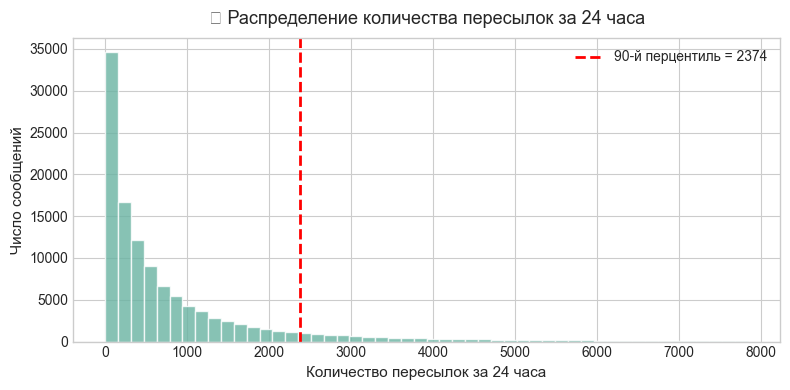

In [64]:
# Убираем экстремальные значения для наглядности
filtered = targets[targets["forwards_h24"] < targets["forwards_h24"].quantile(0.99)]

# Готовим данные для визуализации
q90 = targets["forwards_h24"].quantile(0.9)

plt.figure(figsize=(8, 4))
plt.hist(filtered["forwards_h24"], bins=50, color="#69b3a2", alpha=0.8, edgecolor="white")
plt.axvline(q90, color="red", linestyle="--", linewidth=2, label=f"90-й перцентиль = {int(q90)}")

plt.title("📊 Распределение количества пересылок за 24 часа", fontsize=13, pad=10)
plt.xlabel("Количество пересылок за 24 часа", fontsize=11)
plt.ylabel("Число сообщений", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# уникальная реакция - id + cur_date
# уникальная новость - id